# Linear Regression: A Comprehensive Guide

Linear Regression is one of the fundamental algorithms in machine learning used for predictive analysis. It's a supervised learning algorithm that helps us understand the relationship between dependent (target) and independent (features) variables.

In this notebook, we'll cover:
1. Basic concepts of Linear Regression
2. Data preparation and visualization
3. Model implementation from scratch
4. Using scikit-learn for Linear Regression
5. Model evaluation and interpretation

# Simple Explanation: What Does the Code Below Do?

This notebook shows how to use linear regression, a basic method for predicting numbers.

Imagine you want to predict someone's height based on their age. You collect data (age and height) and draw a straight line that best fits all the points. This line helps you guess the height for any age.

Here's what happens in the code below:
1. We create some example data that follows a simple rule (like height = 2 × age + 1, but with some random noise).
2. We use a computer to find the best straight line that fits this data.
3. We show how to do this step-by-step (from scratch) and also using a popular library called scikit-learn.
4. We check how good our line is at predicting new values.

In short: The code teaches you how to use a straight line to make predictions from data, and how to check if your predictions are accurate.

In [2]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'python -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip.exe')
if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment created at ml_env
Required libraries installed in the virtual environment.
Required libraries installed in the virtual environment.


# 1. Required Libraries

Let's start by importing the necessary libraries:
- NumPy: For numerical computations
- Pandas: For data manipulation
- Matplotlib: For basic plotting
- Seaborn: For statistical visualizations
- Scikit-learn: For machine learning tools

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set the style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

To understand linear regression, let's create a simple dataset with a clear linear relationship. We'll add some noise to make it more realistic.

The relationship will follow the equation: y = 2x + 1 + noise

This means:
- The true slope (coefficient) is 2
- The true intercept is 1
- We'll add random noise to simulate real-world data

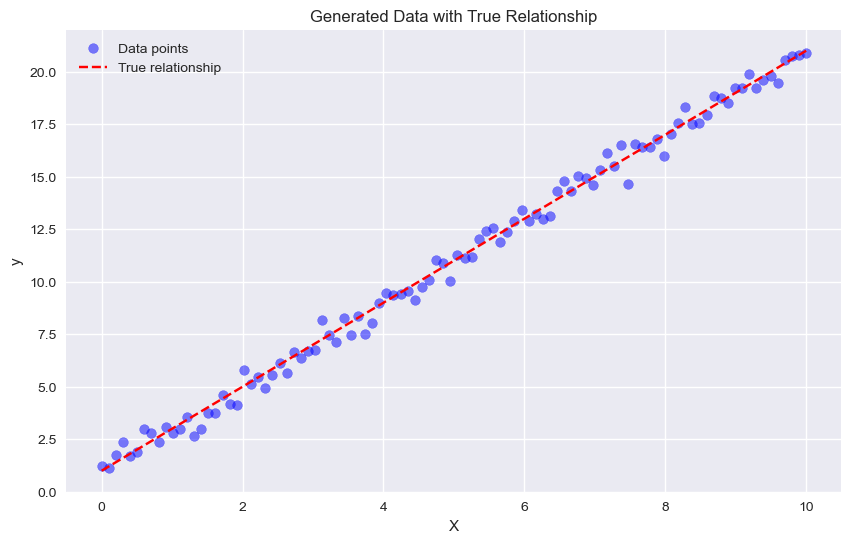

In [4]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate X values
X = np.linspace(0, 10, 100).reshape(-1, 1)

# Generate y values with some noise
y = 2 * X + 1 + np.random.normal(0, 0.5, X.shape)

# Create a DataFrame for better visualization
data = pd.DataFrame({
    'X': X.flatten(),
    'y': y.flatten()
})

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data points')
plt.plot(X, 2*X + 1, color='red', linestyle='--', label='True relationship')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Generated Data with True Relationship')
plt.legend()
plt.grid(True)
plt.show()

# 3. Implementing Linear Regression from Scratch

Before using scikit-learn, let's implement linear regression from scratch to understand the underlying mathematics.

Key concepts:
1. **Linear Relationship**: y = mx + b
   - m: slope (coefficient)
   - b: y-intercept

2. **Cost Function**: Mean Squared Error (MSE)
   - Measures how well our line fits the data
   - Lower MSE means better fit

3. **Gradient Descent**:
   - Algorithm to find the optimal parameters
   - Updates parameters iteratively to minimize the cost function

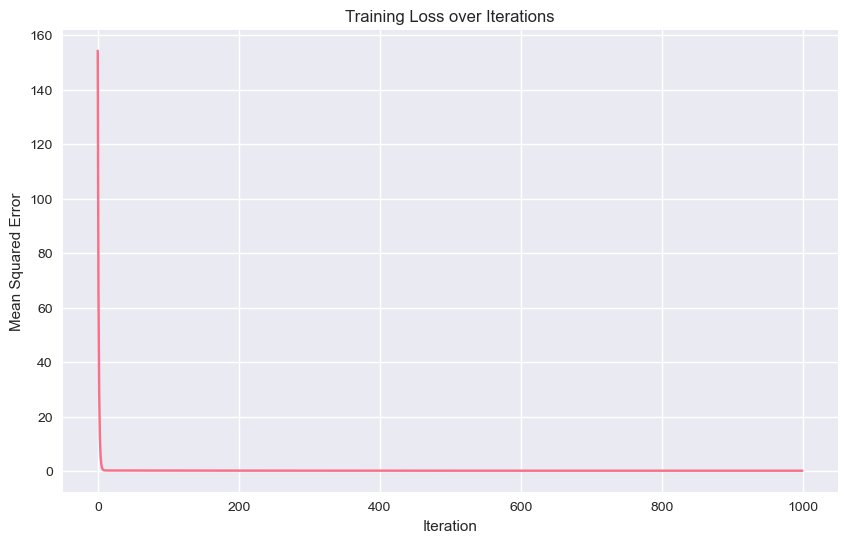

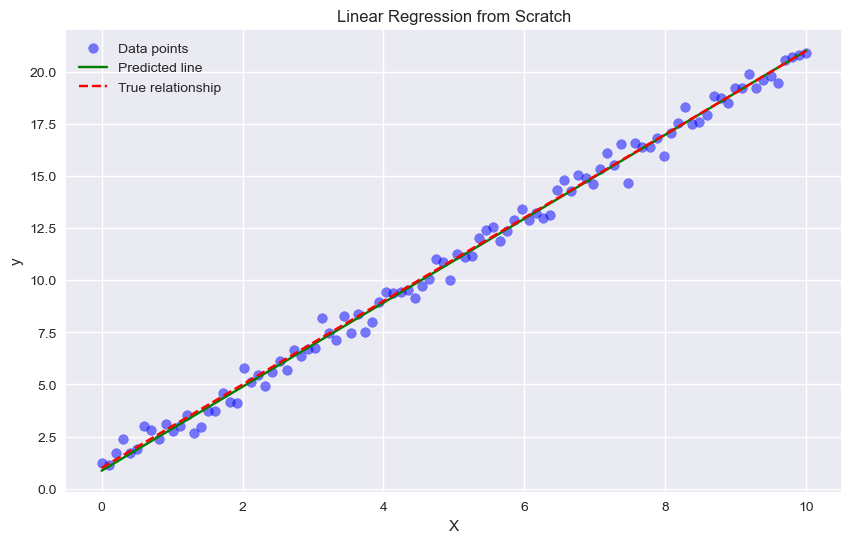

In [6]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.history = {'loss': []}
        
    def fit(self, X, y):
        # Flatten y to ensure it's a 1D array
        y = y.flatten()
        # Initialize parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient descent
        for i in range(self.n_iterations):
            # Forward pass
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Compute gradients
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Compute and store loss
            loss = np.mean((y_predicted - y) ** 2)
            self.history['loss'].append(loss)
            
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Train the model
model_scratch = LinearRegressionScratch(learning_rate=0.01, n_iterations=1000)
model_scratch.fit(X, y)

# Plot the training loss
plt.figure(figsize=(10, 6))
plt.plot(model_scratch.history['loss'])
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Training Loss over Iterations')
plt.grid(True)
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data points')
plt.plot(X, model_scratch.predict(X), color='green', label='Predicted line')
plt.plot(X, 2*X + 1, color='red', linestyle='--', label='True relationship')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression from Scratch')
plt.legend()
plt.grid(True)
plt.show()

# 4. Using Scikit-learn's Linear Regression

Now let's use scikit-learn's implementation of Linear Regression. The advantages of using scikit-learn include:
1. Optimized implementation
2. Consistent API
3. Built-in cross-validation and evaluation metrics
4. Scalability for larger datasets

Coefficient (slope): 2.0060
Intercept: 0.9099

Model Performance:
R² Score: 0.9953
Mean Squared Error: 0.1555


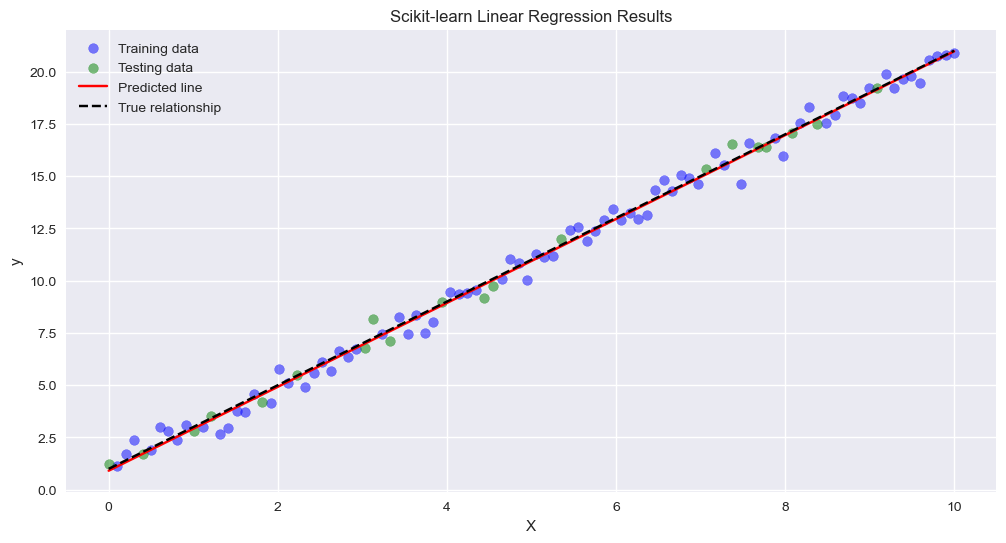

In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)

# Make predictions
y_pred = model_sklearn.predict(X_test)

# Print the model parameters
# Ensure coefficient is a scalar for formatting
coef_scalar = model_sklearn.coef_[0] if np.isscalar(model_sklearn.coef_[0]) else model_sklearn.coef_[0].item()
print(f"Coefficient (slope): {coef_scalar:.4f}")
intercept_scalar = model_sklearn.intercept_.item() if hasattr(model_sklearn.intercept_, "item") else model_sklearn.intercept_
print(f"Intercept: {intercept_scalar:.4f}")
print(f"\nModel Performance:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

# Plot the results
plt.figure(figsize=(12, 6))

# Training data
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training data')
# Testing data
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Testing data')
# Predicted line
plt.plot(X, model_sklearn.predict(X), color='red', label='Predicted line')
# True relationship
plt.plot(X, 2*X + 1, color='black', linestyle='--', label='True relationship')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Scikit-learn Linear Regression Results')
plt.legend()
plt.grid(True)
plt.show()

# 5. Conclusion and Key Takeaways

1. **Linear Regression Basics**:
   - Models linear relationships between variables
   - Uses the equation y = mx + b
   - Simple but powerful for many real-world applications

2. **Implementation Approaches**:
   - From scratch: Helps understand the underlying mathematics
   - Scikit-learn: Optimized for practical use

3. **Model Evaluation**:
   - R² Score: Measures the proportion of variance explained by the model
   - Mean Squared Error: Measures the average squared difference between predictions and actual values

4. **Best Practices**:
   - Split data into training and testing sets
   - Validate model assumptions
   - Consider feature scaling for multiple features
   - Check for outliers and influential points

Linear regression serves as a foundation for understanding more complex machine learning algorithms and is often a good starting point for many predictive modeling tasks.

# 10 Interview Questions & Answers to Understand Linear Regression Better


**1. What is linear regression?**

Linear regression is a statistical method used to model the relationship between a dependent variable and one or more independent variables by fitting a straight line to the data.


**2. What is the equation of a simple linear regression line?**

The equation is: y = mx + b, where y is the predicted value, x is the input feature, m is the slope (coefficient), and b is the intercept.


**3. What does the slope (coefficient) represent in linear regression?**

The slope shows how much the dependent variable changes for a one-unit change in the independent variable.


**4. What is the intercept in linear regression?**

The intercept is the value of the dependent variable when all independent variables are zero.


**5. What is the cost function used in linear regression?**

The most common cost function is Mean Squared Error (MSE), which measures the average squared difference between predicted and actual values.


**6. How does gradient descent work in linear regression?**

Gradient descent is an optimization algorithm that adjusts the model parameters (slope and intercept) to minimize the cost function by taking small steps in the direction of the steepest decrease.


**7. What is overfitting in linear regression?**

Overfitting happens when the model fits the training data too closely, capturing noise instead of the underlying pattern, which leads to poor performance on new data.


**8. How do you evaluate the performance of a linear regression model?**

Common metrics include R² score (explained variance) and Mean Squared Error (MSE). R² shows how well the model explains the variability of the outcome.


**9. Can linear regression be used for classification problems?**

No, linear regression is designed for predicting continuous values, not categories. For classification, algorithms like logistic regression are used.


**10. What assumptions does linear regression make about the data?**

Key assumptions are: linear relationship, independence of errors, homoscedasticity (constant variance of errors), and normally distributed errors.